In [1]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
import scipy
import os
import datetime as dt

import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Input
import tensorflow_addons as tfa


c:\Users\User\Documents\Proyectos Python\TG\venv\Lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


# Carga de datos

In [2]:
url_bel = "https://zenodo.org/records/10723261/files/Weather_data.mat"
mat_file_ws_bel = "..\\data\\Weather_data.mat"

In [3]:
if os.path.exists(mat_file_ws_bel):
    ws_bel = scipy.io.loadmat(mat_file_ws_bel)
    print("Se carga el archivo mat")

else:

    response = requests.get(url_bel)
    # Verificar que la descarga fue exitosa
    if response.status_code == 200:
        with open(mat_file_ws_bel, "wb") as f:
            f.write(response.content)
        print(f"Archivo guardado como: {mat_file_ws_bel}")
        ws_bel = scipy.io.loadmat(mat_file_ws_bel)
        print("Se carga el archivo mat")
    else:
        print(f"Error al descargar: {response.status_code}")

Se carga el archivo mat


# Pre procesamiento

Se convierte a tiempo continuo: desde el formato decha a segundos

In [4]:
date_0 = ws_bel['Date'][0]
date = []
for i in range(0, len(date_0)):
    date = np.append(date, str(date_0[i])[2 : -2])
time_init = dt.datetime(int(date[0][0 : 4]), int(date[0][5 : 7]), int(date[0][8 : 10]), int(date[0][11 : 13]), int(date[0][14 : 16]))
T_nan_index = np.argwhere(pd.isna(date))
date = np.delete(date, T_nan_index[:, 0],  0)
print('Double-check for NaN in time sequence', np.sum(pd.isna(date)))

Double-check for NaN in time sequence 0


In [5]:
Seconds = np.zeros((date.shape[0], 1))
for index in range(date.shape[0]):
    Seconds[index, 0] = ((dt.datetime(int(date[index][0 : 4]), int(date[index][5 : 7]), int(date[index][8 : 10]), int(date[index][11 : 13]), int(date[index][14 : 16])) - time_init).total_seconds())
T_WS = Seconds

Se convierte a coordenadas cartesianas

In [6]:
X_WS = np.array(6378000 * np.sin(np.radians(ws_bel['Lon'])))[0]  # Longitude to meters
Y_WS = np.array(6378000 * np.sin(np.radians(ws_bel['Lat'])))[0]  # Latitude to meters
Z_WS = np.array(ws_bel['Alt'])[0]
Temp_WS = np.array(ws_bel['Temperature'])[0]

Se proyecta la velocidad del viento y la dirección en las coordenadas cartesianas

In [7]:
U_WS = (ws_bel['WindSpeed'] * ws_bel['WindDirectionX'])[0]
V_WS = (ws_bel['WindSpeed'] * ws_bel['WindDirectionY'])[0]

Presión de mbar a Pa

In [8]:
P_WS = ws_bel['Pressure'][0] * 100

Removiendo valores `NaN`

In [9]:
X_WS = np.delete(X_WS, T_nan_index[:, 0],  0)
Y_WS = np.delete(Y_WS, T_nan_index[:, 0],  0)
Z_WS = np.delete(Z_WS, T_nan_index[:, 0],  0)
U_WS = np.delete(U_WS, T_nan_index[:, 0],  0)
V_WS = np.delete(V_WS, T_nan_index[:, 0],  0)
P_WS = np.delete(P_WS, T_nan_index[:, 0],  0)
Temp_WS = np.delete(Temp_WS, T_nan_index[:, 0],  0)

In [10]:
T_WS.shape

(42336, 1)

Se estructura la información en una matriz: 21 estaciones `(filas)` $\times$ medidas cada 10 min `(columnas)`

In [11]:
T_WS = np.reshape(T_WS, (int(T_WS.shape[0] / 21), 21)).T # There are 21 WS stations in this case
X_WS = np.reshape(X_WS, (T_WS.shape[1], T_WS.shape[0])).T
Y_WS = np.reshape(Y_WS, (T_WS.shape[1], T_WS.shape[0])).T
Z_WS = np.reshape(Z_WS, (T_WS.shape[1], T_WS.shape[0])).T
U_WS = np.reshape(U_WS, (T_WS.shape[1], T_WS.shape[0])).T
V_WS = np.reshape(V_WS, (T_WS.shape[1], T_WS.shape[0])).T
P_WS = np.reshape(P_WS, (T_WS.shape[1], T_WS.shape[0])).T
Temp_WS = np.reshape(Temp_WS, (T_WS.shape[1], T_WS.shape[0])).T
print('Number of weather stations:', T_WS.shape[0])

Number of weather stations: 21


Se remueven los valores `NaN`

In [12]:
X_nan_index = np.argwhere(np.isnan(X_WS))
T_WS = np.delete(T_WS, X_nan_index[:, 0],  0)
P_WS = np.delete(P_WS, X_nan_index[:, 0],  0)
U_WS = np.delete(U_WS, X_nan_index[:, 0],  0)
V_WS = np.delete(V_WS, X_nan_index[:, 0],  0)
X_WS = np.delete(X_WS, X_nan_index[:, 0],  0)
Y_WS = np.delete(Y_WS, X_nan_index[:, 0],  0)
Z_WS = np.delete(Z_WS, X_nan_index[:, 0],  0)
Temp_WS = np.delete(Temp_WS, X_nan_index[:, 0],  0)
print('Double-check for NaN in location field', np.sum(np.isnan(X_WS)))

Double-check for NaN in location field 0


Se indica la cantidad de días

In [13]:
n_days = 14 # Change up to a maximum of 14 availsble days
samples =  int(144 * n_days) # Convert selected days to snapshots
T_WS = T_WS[:, : samples]
X_WS = X_WS[:, : samples]
Y_WS = Y_WS[:, : samples]
Z_WS = Z_WS[:, : samples]
U_WS = U_WS[:, : samples]
V_WS = V_WS[:, : samples]
P_WS = P_WS[:, : samples]
Temp_WS = Temp_WS[:, : samples]

Se ordena la matriz con el incremeto de los valores en la coordenada X

In [14]:
for snap in range(0, T_WS.shape[1]):
    index_sort = np.argsort(X_WS[:, snap])
    T_WS[:, snap] = T_WS[index_sort, snap]
    X_WS[:, snap] = X_WS[index_sort, snap]
    Y_WS[:, snap] = Y_WS[index_sort, snap]
    Z_WS[:, snap] = Z_WS[index_sort, snap]
    U_WS[:, snap] = U_WS[index_sort, snap]
    V_WS[:, snap] = V_WS[index_sort, snap]
    P_WS[:, snap] = P_WS[index_sort, snap]
    Temp_WS[:, snap] = Temp_WS[index_sort, snap]

Se eliminan los valores `NaN` de `U`, `V` y `P`

In [15]:
uvp_mean = np.nanmean(np.concatenate([U_WS, V_WS, P_WS], axis = 1), axis = 1)[:, None]
vel_nan_index = np.argwhere(np.isnan(uvp_mean))
T_WS = np.delete(T_WS, vel_nan_index[:, 0],  0)
P_WS = np.delete(P_WS, vel_nan_index[:, 0],  0)
U_WS = np.delete(U_WS, vel_nan_index[:, 0],  0)
V_WS = np.delete(V_WS, vel_nan_index[:, 0],  0)
X_WS = np.delete(X_WS, vel_nan_index[:, 0],  0)
Y_WS = np.delete(Y_WS, vel_nan_index[:, 0],  0)
Z_WS = np.delete(Z_WS, vel_nan_index[:, 0],  0)
Temp_WS = np.delete(Temp_WS, vel_nan_index[:, 0],  0)

Se corrige la presión para el nivel del mar (ISA)

In [16]:
P_WS = P_WS * (1 - 0.0065 * Z_WS / (Temp_WS + 273.15 + 0.0065 * Z_WS))**(-5.257)

Centrando los valores de localización y tiempo

In [17]:
x_min = np.min(X_WS)
x_max = np.max(X_WS)
X_WS = X_WS - (x_min + x_max) / 2
y_min = np.min(Y_WS)
y_max = np.max(Y_WS)
Y_WS = Y_WS - (y_min + y_max) / 2
t_min = np.min(T_WS)
t_max = np.max(T_WS)
T_WS = T_WS - t_min # Refer to t = 0

In [18]:
Y_WS.shape, X_WS.shape, T_WS.shape

print(
    T_WS[1,:9],"\n",
    X_WS[1,:9],"\n",
    Y_WS[1,:9],"\n",
)

[   0.  600. 1200. 1800. 2400. 3000. 3600. 4200. 4800.] 
 [-143638.70673808 -143638.70673808 -143638.70673808 -143638.70673808
 -143638.70673808 -143638.70673808 -143638.70673808 -143638.70673808
 -143638.70673808] 
 [30967.31993582 30967.31993582 30967.31993582 30967.31993582
 30967.31993582 30967.31993582 30967.31993582 30967.31993582
 30967.31993582] 



### Cuadricula de salida para la PINN

In [19]:
T_PINN = T_WS[0 : 1, :] # Same times for reconstruction

Resolución en grados $R = 0.2$

In [20]:
R = 0.2
R_PINN = 6378000 * np.sin(np.radians(R)) # Grid resolution
x_PINN = np.arange(x_min - R_PINN, x_max + R_PINN, R_PINN) # X values in output resolution
y_PINN = np.arange(y_min - R_PINN, y_max + R_PINN, R_PINN) # Y values in output resolution

Centrando la información de localización

In [21]:
x_PINN = x_PINN - (x_min + x_max) / 2
y_PINN = y_PINN - (y_min + y_max) / 2

In [22]:
x_PINN.shape,y_PINN.shape

((20,), (8,))

Cuadricula de salida final

In [23]:
X_PINN, Y_PINN = np.meshgrid(x_PINN, y_PINN)
X_PINN = X_PINN.flatten('F')[:, None]
Y_PINN = Y_PINN.flatten('F')[:, None]

Dimensiones

In [24]:
print(f"{T_PINN.shape=}")
print(f"{X_PINN.shape=}")
print(f"{Y_PINN.shape=}")

T_PINN.shape=(1, 2016)
X_PINN.shape=(160, 1)
Y_PINN.shape=(160, 1)


In [25]:
dim_T_PINN = T_PINN.shape[1]
dim_N_PINN = X_PINN.shape[0]

T_PINN = np.tile(T_PINN, (dim_N_PINN, 1))
X_PINN = np.tile(X_PINN, dim_T_PINN)
Y_PINN = np.tile(Y_PINN, dim_T_PINN)

In [26]:
print(f"{T_PINN.shape=}")
print(f"{X_PINN.shape=}")
print(f"{Y_PINN.shape=}")

T_PINN.shape=(160, 2016)
X_PINN.shape=(160, 2016)
Y_PINN.shape=(160, 2016)


Valores de referencia para la no-dimensionalización

In [27]:
L = np.sqrt((x_max - x_min) ** 2 + (y_max - y_min) ** 2) # Reference distance
W = np.sqrt(np.nanmax(abs(U_WS)) ** 2 + np.nanmax(abs(V_WS)) ** 2) # Reference velocity
rho = 1.269 # Air density at 15 degrees
nu = 1.382e-5 # Kinematic viscosity at 15 degrees
Re = int(W * L / nu) # Reynolds number
P0 = np.nanmean(P_WS) # Reference pressure level
print('L:', L, 'W', W, 'P0', P0, 'Re', Re)

L: 409791.6159110926 W 16.718180196652117 P0 100359.48707895375 Re 495728659759


No-dimensonalización

In [28]:
X_WS = X_WS / L
Y_WS = Y_WS / L
T_WS = T_WS * W / L
P_WS = (P_WS - P0) / rho / (W ** 2)
U_WS = U_WS / W
V_WS = V_WS / W

X_PINN = X_PINN / L
Y_PINN = Y_PINN / L
T_PINN = T_PINN * W / L

In [29]:
# Validation cases (remove stations)
# # N_test = 0 # Number of stations to remove
WS_val = np.array([1, 2, 3, 5, 7, 9, 10, 11, 13, 14, 15, 16, 19])
# Choose between different arrays for desired validation case:
# Close: np.array([2, 8, 10, 14, 16, 19])
# Far: np.array([0, 1, 4, 6, 8, 12, 17, 18, 19, 20])
# Envelope: np.array([1, 2, 3, 5, 7, 9, 10, 11, 13, 14, 15, 16, 19])

Se remueven WS para validación

In [30]:
T_val = T_WS[WS_val, :]
P_val = P_WS[WS_val, :]
U_val = U_WS[WS_val, :]
V_val = V_WS[WS_val, :]
X_val = X_WS[WS_val, :]
Y_val = Y_WS[WS_val, :]
Z_val = Z_WS[WS_val, :]

El resto de las WS para entrenamiento

In [31]:
T_WS = np.delete(T_WS, WS_val, 0)
P_WS = np.delete(P_WS, WS_val, 0)
U_WS = np.delete(U_WS, WS_val, 0)
V_WS = np.delete(V_WS, WS_val, 0)
X_WS = np.delete(X_WS, WS_val, 0)
Y_WS = np.delete(Y_WS, WS_val, 0)
print('Number of final weather stations available for training:', T_WS.shape[0])

Number of final weather stations available for training: 8


Dimensión

In [32]:
dim_N_WS = X_WS.shape[0]
dim_T_WS = X_WS.shape[1]

# del WS_data

# Carga y uso de la PINN

In [38]:
# Training
# num_epochs = 5 # number of epochs
num_epochs = 1000 # number of epochs
lamb = 2 # Tuning of physics constraints
batch_PINN = int(np.ceil((dim_N_PINN * dim_T_PINN / n_days * R)))
batch_WS = int(np.ceil(dim_N_WS * dim_T_WS / n_days * R))

In [39]:
# Data dimensions
dim_N_data = dim_N_WS
dim_T_data = dim_T_WS
dim_T_eqns = dim_T_PINN
dim_N_eqns = dim_N_PINN

Se carga la arquitectura de la red neuronal, y luego se carga el la red ya entrenada.

In [33]:
# ========================== #
# === Capa personalizada === #
# ========================== #
class GammaBiasLayer(tf.keras.layers.Layer):
    def __init__(self, units, *args, **kwargs):
        super(GammaBiasLayer, self).__init__(*args, **kwargs)
        self.units = units

    def build(self, input_shape):
        self.bias = self.add_weight(
            'bias', shape=(self.units,), initializer='zeros', trainable=True
        )
        self.gamma = self.add_weight(
            'gamma', shape=(self.units,), initializer='ones', trainable=True
        )
        # WeightNormalization requiere tensorflow_addons
        self.w = tfa.layers.WeightNormalization(
            Dense(
                self.units,
                use_bias=False,
                kernel_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1),
                trainable=True,
                activation=None
            )
        )

    def call(self, input_tensor):
        return self.gamma * self.w(input_tensor) + self.bias


In [34]:
# ========================== #
# = Reproducibilidad total = #
# ========================== #
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [35]:
model_path = "PINN_model_epoch_1000_lambda_2_R_0.2"

In [36]:
model = load_model(filepath=model_path, 
                   custom_objects={'GammaBiasLayer': GammaBiasLayer})

In [42]:
t_eqns = T_PINN[:, :][:,:].flatten()[:,None]
x_eqns = X_PINN[:, :][:,:].flatten()[:,None]
y_eqns = Y_PINN[:, :][:,:].flatten()[:,None]

In [46]:
SX = tf.concat([t_eqns, x_eqns, y_eqns], axis=1)
SY = model(SX)

In [78]:
np.unique(SX[:,2], return_counts=True)

(array([-0.20166115, -0.14733262, -0.0930041 , -0.03867557,  0.01565296,
         0.06998148,  0.12431001,  0.17863854]),
 array([40320, 40320, 40320, 40320, 40320, 40320, 40320, 40320],
       dtype=int64))

In [79]:
np.reshape(SX[:,2], (-1, 40320))[:,0]

array([-0.20166115,  0.01565296, -0.20166115,  0.01565296, -0.20166115,
        0.01565296, -0.20166115,  0.01565296])

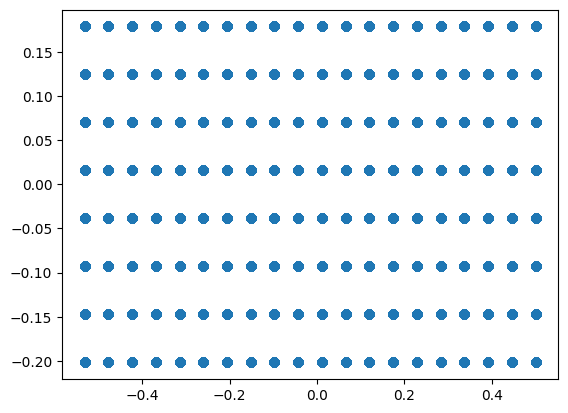

In [82]:
plt.scatter(
np.reshape(SX[:,1], (-1, 16128)),#[:,0],
np.reshape(SX[:,2], (-1, 16128))#[:,0],
)
plt.show()